# Task 1: Condition Classification
Can a classifier identify which treatment condition a cell came from using its gene expression profile? Which genes drive the separation?
Train one or more classification model**s (logistic regression, tree ensembles or neural networ**k), depending on group size
:
a) One student: Choose one type of model,
b) Groups with two students: Choose two types of models.
c) Groups with three students: Train one of e
ach.
For each model you train, compute feature importance and discuss the results

**Experimental setup**
Design your experiment appropriately, e.g., using one of the data splitting strategies presented in Lecture 4. Justify your choices.
Evaluate the influence of relevant model parameters and justify your choices. For example, for k-means clustering, you might set k = 3 and mention that you expect the data to be separable into three classes based on your previous PCA plot, or you might train several models with different k and evaluate which one is best for the task using suitable metrics.

**Model evaluation**
We expect you to design your models carefully to improve their performance. However, for your grade, how well the model actually performs is less important than a sensible and thorough evaluation of the model’s performance, using suitable metrics.
For tasks 1 and 3: If multiple models are trained, compare results of your models, including in the context of the bias-variance tradeoff. Give a hypothesis describing the differences you see between models.

## 0.Setup

In [1]:
import numpy as np
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GroupKFold, 
    cross_val_score,
    GridSearchCV, # New
    validation_curve # New
)

from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
 accuracy_score,
 balanced_accuracy_score,
 precision_score,
 recall_score,
 f1_score,
 roc_auc_score,
 average_precision_score,
 log_loss,
 brier_score_loss,
 confusion_matrix,
 classification_report,
 RocCurveDisplay,
 PrecisionRecallDisplay,
 ConfusionMatrixDisplay,
 auc, roc_curve
)

from sklearn.inspection import permutation_importance

In [3]:
INPUT_FILE = '/home/ubuntu/data/frangieh/rna.strictqc.hvg100.h5ad' # 100 HVG 
# INPUT_FILE ='/home/ubuntu/data/frangieh/rna.qc.hvg200.h5ad'
sc.settings.verbosity = 1
RANDOM_STATE = 1

In [4]:
adata = ad.read_h5ad(INPUT_FILE)

In [5]:
adata.X = adata.layers['counts']

## 1.Data prep

### 1.1 Class labels

In [6]:
# original_columns = [ 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 
#                     'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 
#                     'disease', 'perturbation_type', 'celltype', 'organism', 
#                     'perturbation_type_2', 'nperts', 'ngenes']
# adata.obs[original_columns].head()

Following the example workflow from Lecture 4, we start of by looking into the class counts in our dataset and look for potential class imbalance. The labels are stored in the column `perturbation_2`.

In [7]:
# Class raw counts
print(adata.obs['perturbation_2'].value_counts())

perturbation_2
IFNγ          52307
Co-culture    33008
Control       32794
Name: count, dtype: int64


In [8]:
# Class fractions
print(adata.obs['perturbation_2'].value_counts()/adata.n_obs)

perturbation_2
IFNγ          0.442871
Co-culture    0.279471
Control       0.277659
Name: count, dtype: float64


From these outputs, we see that the majority of cells in our dataset are from IFNy culture, followed by the cells from the co-culture and the Control cells having the lowes number, about 26% of the entire dataset.

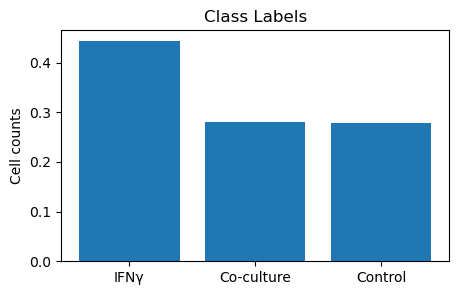

In [9]:
plt.figure(figsize=(5, 3))
plt.bar([1,2,3], adata.obs['perturbation_2'].value_counts()/adata.n_obs)
plt.title('Class Labels')
plt.ylabel("Cell counts")
plt.xticks([1,2,3], adata.obs['perturbation_2'].value_counts().index.to_list())
plt.show()

### 1.2 Feature Selection

Since we labeled the 5000 most variable genes during the preprocessing, we can use those to reduce the feature space.

In [10]:
adata = adata[:,adata.var['highly_variable']==True].copy()
adata

AnnData object with n_obs × n_vars = 118109 × 100
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersio

### 1.3 Data Prep

#### 1.3.1 Export as arrays

In [11]:
# Function adatpted from Lecture 4
def data_prep(adata, y_col):
    """
    Prepare X and Y for classification from a given AnnData object.
    -------------------------------------------------
    Args:
        adata (AnnData Object): AnnData object of the dataset.
        y_col (str): A string indicating the column in adata.obs to be used as a label.
    Returns:
        X (numpy.array): a numpy array containing the gene expression data from the dataset.
        y (numpy.array): a numpy array containing the labels to be used for training.
    """
    
    if hasattr(adata.X, "toarray"): # Taken from Lecture 4
        X = adata.X.toarray()
    else:
        X = adata.X
    
    y = adata.obs[y_col].to_numpy().astype(str)
    
    return X, y

In [12]:
X_full, y_full = data_prep(adata, y_col='perturbation_2')

In [13]:
print('X: ', X_full) 
print('Y: ', y_full)

X:  [[0. 1. 0. ... 0. 0. 0.]
 [0. 2. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 7. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 0.]]
Y:  ['Control' 'Control' 'Control' ... 'Co-culture' 'Co-culture' 'Co-culture']


In [14]:
print(np.unique(y_full, return_counts=True))

(array(['Co-culture', 'Control', 'IFNγ'], dtype='<U10'), array([33008, 32794, 52307]))


In [15]:
# Because the kernel keeps crashing, I am limiting the data size to 5% of the entire data
X_rest, X, y_rest, y = train_test_split(
    X_full, y_full, 
    test_size=0.05, 
    stratify=y_full, 
    random_state=RANDOM_STATE,
)

In [16]:
print('X: ', X.shape)
print('y: ', y.shape)
print(np.unique(y, return_counts=True))

X:  (5906, 100)
y:  (5906,)
(array(['Co-culture', 'Control', 'IFNγ'], dtype='<U10'), array([1650, 1640, 2616]))


#### 1.3.2 Training/Validation/Testing Splitting

- The training set is used to fit preprocessing parameters and model coefficients. The validation set is used to choose hyperparameters such as C, penalty, solver, and class_weight. The test set is kept untouched until the end to estimate final generalization performance. Scikit-learn’s train_test_split can randomly split arrays and supports stratify, which preserves class proportions across splits.
 
- For classification, stratification is important because accuracy, precision, recall, F1, ROC AUC, and PR AUC can become misleading if the training, validation, or test set has a materially different class distribution from the original dataset. Scikit-learn documents stratify as a way to split data in a stratified fashion using class labels.. For more information on the `stratify` argument see [this link](https://scikit-learn.org/stable/modules/cross_validation.html#stratification)



In [17]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=RANDOM_STATE,
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, #CHECK
    test_size=0.25, #CHECK
    stratify=y_temp, #CHECK
    random_state=RANDOM_STATE,
)

In [18]:
print('X_train: ', X_train.shape)
print('y_train: ', y_train.shape)
print(np.unique(y_train, return_counts=True))
print('X_valid: ', X_valid.shape)
print('y_valid; ', y_valid.shape)
print(np.unique(y_valid, return_counts=True))
print('X_test: ', X_test.shape)
print('y_test; ', y_test.shape)
print(np.unique(y_test, return_counts=True))

X_train:  (3543, 100)
y_train:  (3543,)
(array(['Co-culture', 'Control', 'IFNγ'], dtype='<U10'), array([ 990,  984, 1569]))
X_valid:  (1181, 100)
y_valid;  (1181,)
(array(['Co-culture', 'Control', 'IFNγ'], dtype='<U10'), array([330, 328, 523]))
X_test:  (1182, 100)
y_test;  (1182,)
(array(['Co-culture', 'Control', 'IFNγ'], dtype='<U10'), array([330, 328, 524]))


## 2. Modeling

**Pipeline setup**

Scaling is especially important for logistic regression with regularization because the penalty acts on coefficient magnitudes. If features are on very different scales, regularization may penalize some variables more than others for reasons unrelated to predictive value.
 
It is important to note here, that the `StandardScaler` is placed inside the `Pipeline` so that the scaler is fit only on the training data during each cross-validation fold, which helps avoid leakage from validation or test data into training transformations..

### 2.1 Logistic Regression

In [19]:
logreg_pipeline = Pipeline(
    steps=[("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, 
                                         random_state=RANDOM_STATE)),
          ]
)

#### Hyperparameter tuning

`StratifiedKFold`: This cross-validation object is a variation of KFold that returns stratified folds. The folds are made by preserving the percentage of samples for each class in y in a binary or multiclass classification setting.


In [20]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

In [21]:
logreg_param_grid = [
    {
        "model__solver": ["lbfgs"],
        "model__l1_ratio": [0],
        "model__C": np.logspace(-4, 4, 4),
        "model__class_weight": [None, "balanced"]
    },
    # {
        # "model__solver": ["liblinear"],
        # "model__penalty": ["l1", "l2"],
        # "model__C": np.logspace(-4, 4, 9),
        # "model__class_weight": [None, "balanced"]
    # },
    {
        "model__solver": ["saga"],
        "model__l1_ratio": [0.1, 0.5, 0.9],
        "model__C": np.logspace(-4, 4, 4),
        "model__class_weight": [None, "balanced"]
}
]

In [22]:
logreg_grid = GridSearchCV(
    estimator=logreg_pipeline, 
    param_grid=logreg_param_grid,
    scoring=None,
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
)

In [23]:
logreg_grid.fit(X_train, y_train)

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'model__C': array([1.0000...00000000e+04]), 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0], 'model__solver': ['lbfgs']}, {'model__C': array([1.0000...00000000e+04]), 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0.1, 0.5, ...], 'model__solver': ['saga']}]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using

In [24]:
print("Best score:", logreg_grid.best_score_)
print("Best parameters:", logreg_grid.best_params_)
best_logreg = logreg_grid.best_estimator_

Best score: 0.7132373694609089
Best parameters: {'model__C': np.float64(10000.0), 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'lbfgs'}


### 2.2 Decision Tree

In [25]:
tree_pipeline = Pipeline(steps=[
    # ("scaler", StandardScaler()),
    ("model", DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

In [26]:
tree_param_grid = {
    "model__criterion": ["gini", "entropy", "log_loss"],
    "model__max_depth": [100, 200, None],
    "model__min_samples_split": [10, 20, 30, 40, 50],
    "model__class_weight": [None, "balanced"],
    "model__ccp_alpha": [0.001, 0.005, 0.0075, 0.01]
}

In [27]:
tree_grid = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_param_grid,
    scoring=None,
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

In [28]:
tree_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=1))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__ccp_alpha': [0.001, 0.005, ...], 'model__class_weight': [None, 'balanced'], 'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [100, 200, ...], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_`

In [29]:
print("Best score: ", tree_grid.best_score_)
print("Best parameters: ", tree_grid.best_params_)

Best score:  0.6423934518769405
Best parameters:  {'model__ccp_alpha': 0.001, 'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 100, 'model__min_samples_split': 10}


## 3. Evaluation - Validation set 

In [30]:
def evaluate_model(model, X_true, y_true,  classes, return_predictions = False):

    y_prob = model.predict_proba(X_true)
    y_pred = model.predict(X_true)
    model_desc = model.get_params()['model']
    print(model_desc)
    print("accuracy         :", round(accuracy_score(y_true, y_pred), 3))
    print("balanced acc.    :", round(balanced_accuracy_score(y_true, y_pred), 3))
    print("f1               :", round(f1_score(y_true, y_pred, average='macro'), 3))
    print("precision        :", round(precision_score(y_true, y_pred, average='macro'), 3))
    print("recall           :", round(recall_score(y_true, y_pred, average='macro'), 3))
    print()
    print("macro AUROC (OvR):", round(roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro", labels=classes), 3))
    # macro AUCPR
    aps = []
    for i, c in enumerate(classes):
        aps.append(average_precision_score((y_true == c).astype(int), y_prob[:, i]))
    print("macro AUCPR      :", round(float(np.mean(aps)), 3))
    print()
    print(classification_report(y_true, y_pred, digits=3))

    plt.figure()
    plt.title(f'ROC - {str(model_desc)}')
    for i, label in enumerate(np.unique(y)):
        fpr, tpr, thresholds = roc_curve((y_true == label).astype(int), y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{label} - ROC curve (area = %0.5f)' % roc_auc)
    plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
    plt.xlim([-0.1, 1.05])
    plt.ylim([-0.1, 1.05])
    plt.legend()
    plt.show()
    
    if return_predictions:
        return y_prob, y_pred

In [31]:
def plot_ConfMatrix(model, X_true, y_true):
    # Plot non-normalized confusion matrix
    titles_options = [
        ("Confusion matrix, without normalization", None),
        ("Normalized confusion matrix", "true"),
    ]
    for title, normalize in titles_options:
        disp = ConfusionMatrixDisplay.from_estimator(
            model,
            X_valid,
            y_valid,
            cmap=plt.cm.Blues,
            normalize=normalize,
        )
        disp.ax_.set_title(title)
    plt.show()

### 3.1 Logistic Regression

LogisticRegression(C=np.float64(10000.0), l1_ratio=0, max_iter=2000,
                   random_state=1)
accuracy         : 0.711
balanced acc.    : 0.708
f1               : 0.705
precision        : 0.702
recall           : 0.708

macro AUROC (OvR): 0.881
macro AUCPR      : 0.786

              precision    recall  f1-score   support

  Co-culture      0.682     0.727     0.704       330
     Control      0.649     0.671     0.660       328
        IFNγ      0.776     0.727     0.750       523

    accuracy                          0.711      1181
   macro avg      0.702     0.708     0.705      1181
weighted avg      0.714     0.711     0.712      1181



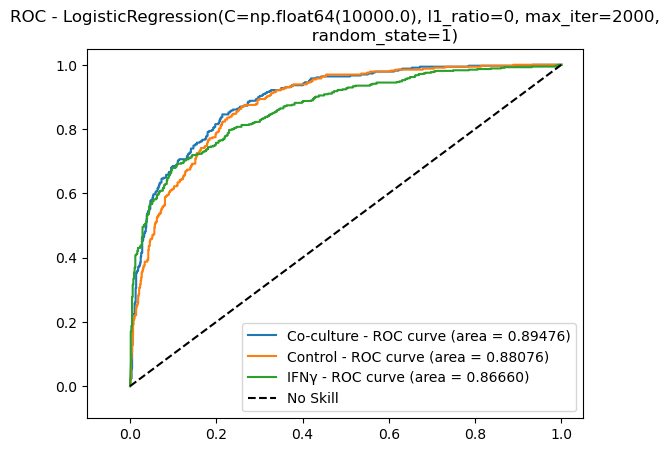

In [32]:
valid_prob_logreg, valid_pred_logreg = evaluate_model(best_logreg, X_valid, y_valid, classes=np.unique(y), return_predictions=True)
# evaluate_model(best_logreg, X_valid, y_valid, classes=np.unique(y))

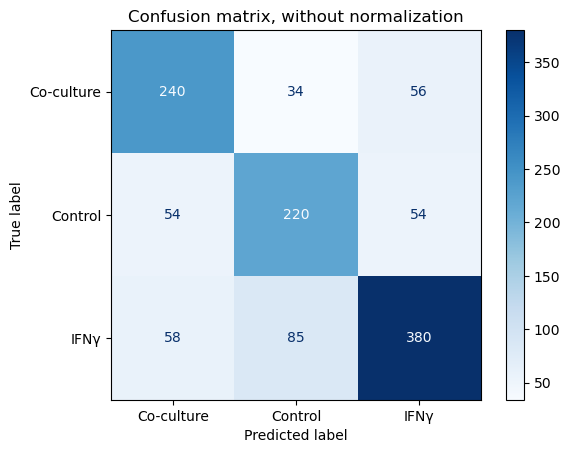

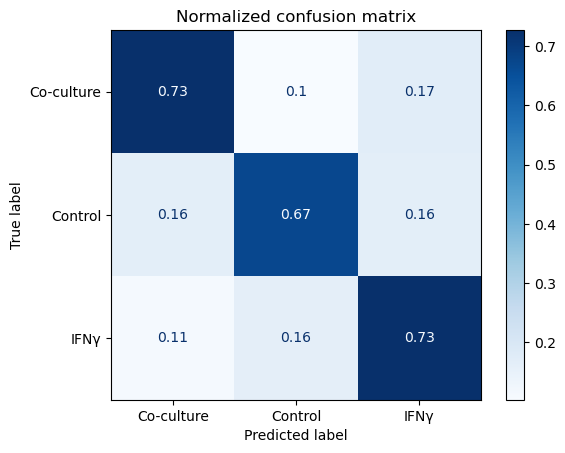

In [33]:
# # Plot non-normalized confusion matrix
# titles_options = [
#     ("Confusion matrix, without normalization", None),
#     ("Normalized confusion matrix", "true"),
# ]
# for title, normalize in titles_options:
#     disp = ConfusionMatrixDisplay.from_estimator(
#         best_logreg,
#         X_valid,
#         y_valid,
#         cmap=plt.cm.Blues,
#         normalize=normalize,
#     )
#     disp.ax_.set_title(title)
# plt.show()

plot_ConfMatrix(best_logreg, X_valid, y_valid)

In [34]:
# plt.figure()  
# for i, label in enumerate(np.unique(y)):
#     fpr, tpr, thresholds = roc_curve((y_valid == label).astype(int), valid_prob[:, i])
#     roc_auc = auc(fpr, tpr)
#     plt.plot(fpr, tpr, label=f'{label} - ROC curve (area = %0.5f)' % roc_auc)
# plt.plot([0, 1], [0, 1], 'k--', label='No Skill')
# plt.xlim([-0.1, 1.05])
# plt.ylim([-0.1, 1.05])
# plt.legend()
# plt.show()

### 3.2 Decisoin Tree

In [35]:
best_tree = tree_grid.best_estimator_

DecisionTreeClassifier(ccp_alpha=0.001, class_weight='balanced', max_depth=100,
                       min_samples_split=10, random_state=1)
accuracy         : 0.665
balanced acc.    : 0.677
f1               : 0.662
precision        : 0.67
recall           : 0.677

macro AUROC (OvR): 0.816
macro AUCPR      : 0.677

              precision    recall  f1-score   support

  Co-culture      0.577     0.682     0.625       330
     Control      0.582     0.747     0.654       328
        IFNγ      0.851     0.602     0.705       523

    accuracy                          0.665      1181
   macro avg      0.670     0.677     0.662      1181
weighted avg      0.700     0.665     0.669      1181



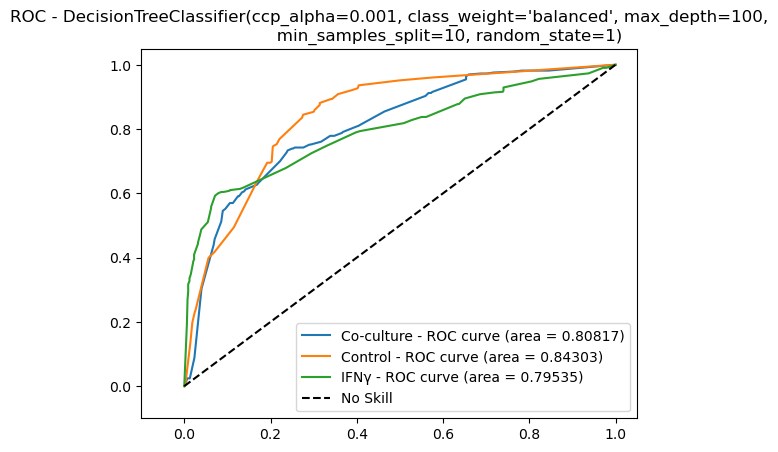

In [36]:
valid_prob_tree, valid_pred_tree = evaluate_model(best_tree, X_valid, y_valid, classes=np.unique(y), return_predictions=True)

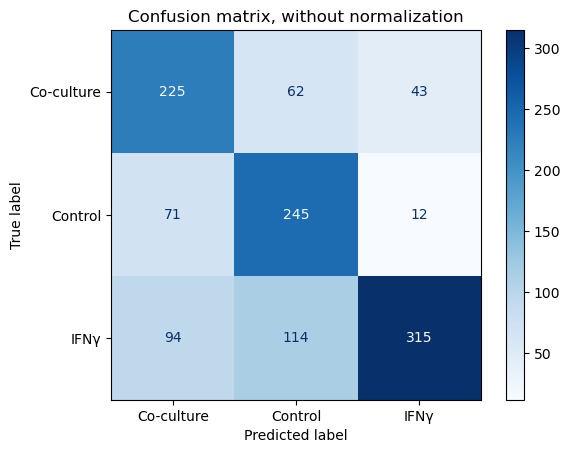

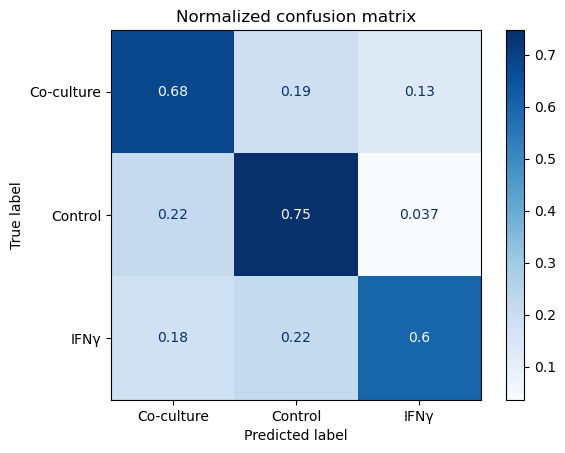

In [37]:
plot_ConfMatrix(best_tree, X_valid, y_valid)

## 4. Optional threshold tuning on validation set

- Method: Prediction / Class frequency = Adapted prediction Score

In [38]:
print(np.unique(y, return_counts = True))
freq = np.unique(y, return_counts = True)[1]/y.shape
print(freq)

(array(['Co-culture', 'Control', 'IFNγ'], dtype='<U10'), array([1650, 1640, 2616]))
[0.2793769  0.27768371 0.44293938]


In [39]:
# ## Test case (established with the previous verison of Logistic Regression)
# index = 1180
# print('y_valid (Ground Truth): ', y_valid[index])
# print('valid_pred (Prediction): ', valid_pred[index])
# print('valid_prob (Prediction probabilities): ',valid_prob[index])
# print('class-frequency corrrected score: ',valid_prob[index] / freq)
# new_pred = np.argmax(valid_prob[index] / freq)
# print('New Prediction index: ', new_pred)
# print('New Prediction class: ', np.unique(y)[new_pred])

In [40]:
def adjT_evaluation(y_true, y_prob, y_pred, class_freqs, classes, return_array = False):
    adj_valid_pred = []
    for element in (y_prob / class_freqs):
        i = np.argmax(element)
        adj_valid_pred.append(classes[i])
    adj_valid_pred = np.array(adj_valid_pred)
    print("Performance metrics:")
    print("accuracy         :", round(accuracy_score(y_true, y_pred), 3))
    print("balanced acc.    :", round(balanced_accuracy_score(y_true, y_pred), 3))
    print("f1               :", round(f1_score(y_true, y_pred, average='macro'), 3))
    print("precision        :", round(precision_score(y_true, y_pred, average='macro'), 3))
    print("recall           :", round(recall_score(y_true, y_pred, average='macro'), 3))
    print()
    print("Performance metrics using class-frequency adjusted scores:")
    print("accuracy         :", round(accuracy_score(y_true, adj_valid_pred), 3))
    print("balanced acc.    :", round(balanced_accuracy_score(y_true, adj_valid_pred), 3))
    print("f1               :", round(f1_score(y_true, adj_valid_pred, average='macro'), 3))
    print("precision        :", round(precision_score(y_true, adj_valid_pred, average='macro'), 3))
    print("recall           :", round(recall_score(y_true, adj_valid_pred, average='macro'), 3))
    if return_array:
        return adj_valid_pred

### 4.1 Logistic Regression

In [41]:
adjT_evaluation(y_valid, valid_prob_logreg, valid_pred_logreg, freq, np.unique(y))

Performance metrics:
accuracy         : 0.711
balanced acc.    : 0.708
f1               : 0.705
precision        : 0.702
recall           : 0.708

Performance metrics using class-frequency adjusted scores:
accuracy         : 0.703
balanced acc.    : 0.718
f1               : 0.701
precision        : 0.705
recall           : 0.718


**Conclusion:** There seems to be a slight improvement in the balanced accuracy, but other than that, the class-frequency adjusment doesn't seem to imporve the model perfomance by a lot.

### 4.2 Decision Tree

In [42]:
adjT_evaluation(y_valid, valid_prob_tree, valid_pred_tree, freq, np.unique(y))

Performance metrics:
accuracy         : 0.665
balanced acc.    : 0.677
f1               : 0.662
precision        : 0.67
recall           : 0.677

Performance metrics using class-frequency adjusted scores:
accuracy         : 0.649
balanced acc.    : 0.668
f1               : 0.647
precision        : 0.665
recall           : 0.668


## 5. Final unseen test set evaluation

### 5.1 Logistic Regression

LogisticRegression(C=np.float64(10000.0), l1_ratio=0, max_iter=2000,
                   random_state=1)
accuracy         : 0.725
balanced acc.    : 0.723
f1               : 0.719
precision        : 0.716
recall           : 0.723

macro AUROC (OvR): 0.891
macro AUCPR      : 0.793

              precision    recall  f1-score   support

  Co-culture      0.692     0.742     0.716       330
     Control      0.666     0.692     0.679       328
        IFNγ      0.791     0.735     0.762       524

    accuracy                          0.725      1182
   macro avg      0.716     0.723     0.719      1182
weighted avg      0.728     0.725     0.726      1182



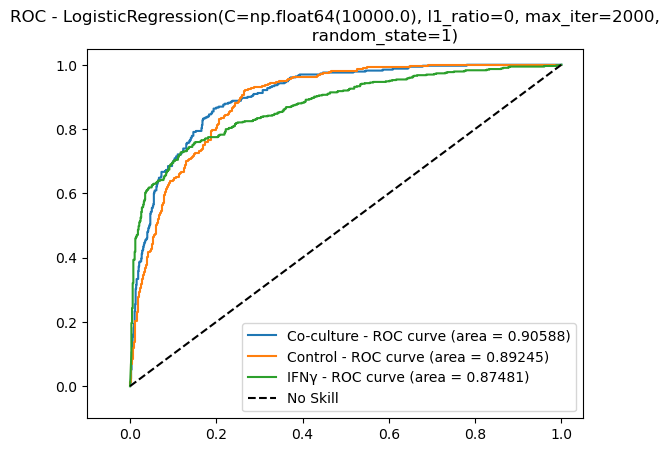

In [43]:
test_prob_logreg, test_pred_logreg = evaluate_model(best_logreg, X_test, y_test, classes=np.unique(y), return_predictions=True)

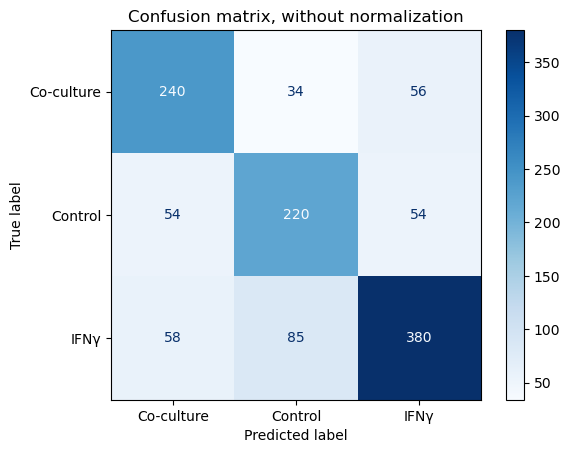

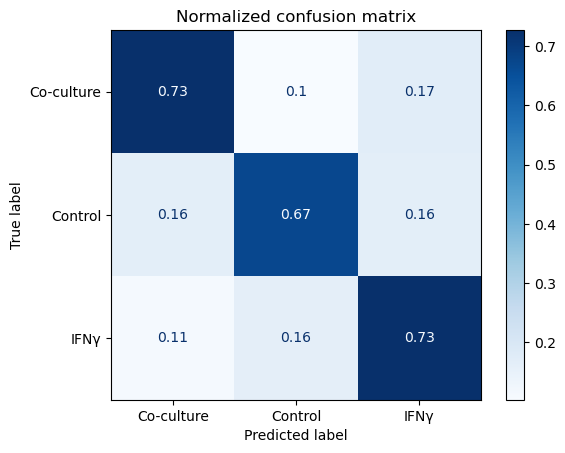

In [44]:
plot_ConfMatrix(best_logreg, X_test, y_test)

### 5.2 Decision Tree

DecisionTreeClassifier(ccp_alpha=0.001, class_weight='balanced', max_depth=100,
                       min_samples_split=10, random_state=1)
accuracy         : 0.685
balanced acc.    : 0.697
f1               : 0.682
precision        : 0.693
recall           : 0.697

macro AUROC (OvR): 0.841
macro AUCPR      : 0.706

              precision    recall  f1-score   support

  Co-culture      0.639     0.676     0.657       330
     Control      0.568     0.793     0.662       328
        IFNγ      0.872     0.624     0.727       524

    accuracy                          0.685      1182
   macro avg      0.693     0.697     0.682      1182
weighted avg      0.722     0.685     0.689      1182



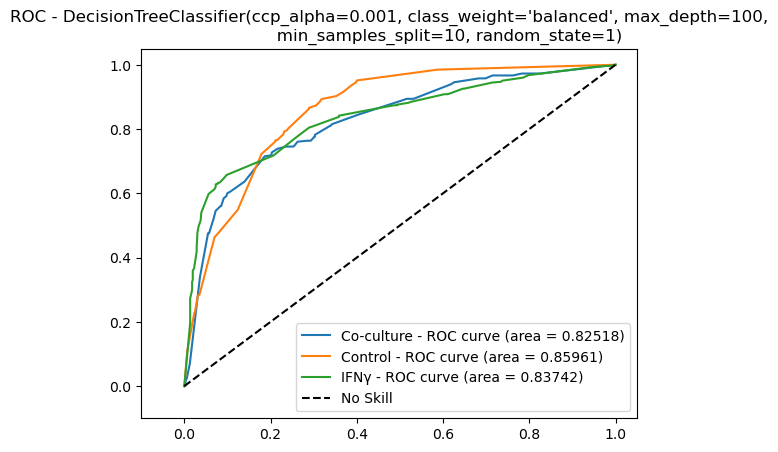

In [45]:
evaluate_model(best_tree, X_test, y_test, classes=np.unique(y))

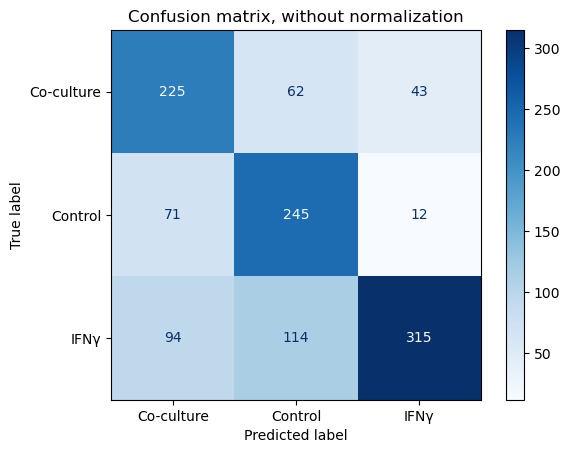

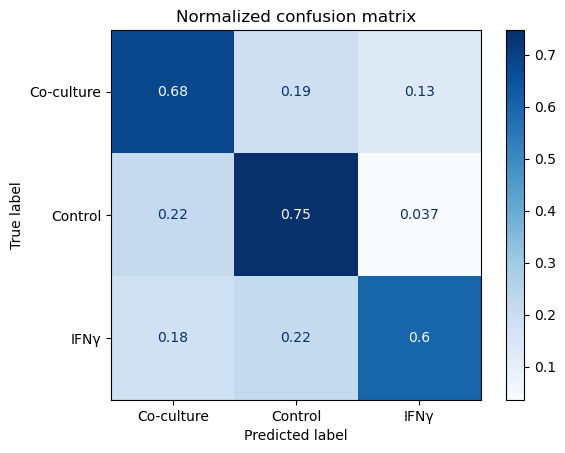

In [46]:
plot_ConfMatrix(best_tree, X_test, y_test)

## 6. Model Interpretation

- Feature importance

- Model results discussion 

### 6.1 Logistic Regression

#### 6.1.1 Logistic Regression - Coefficients

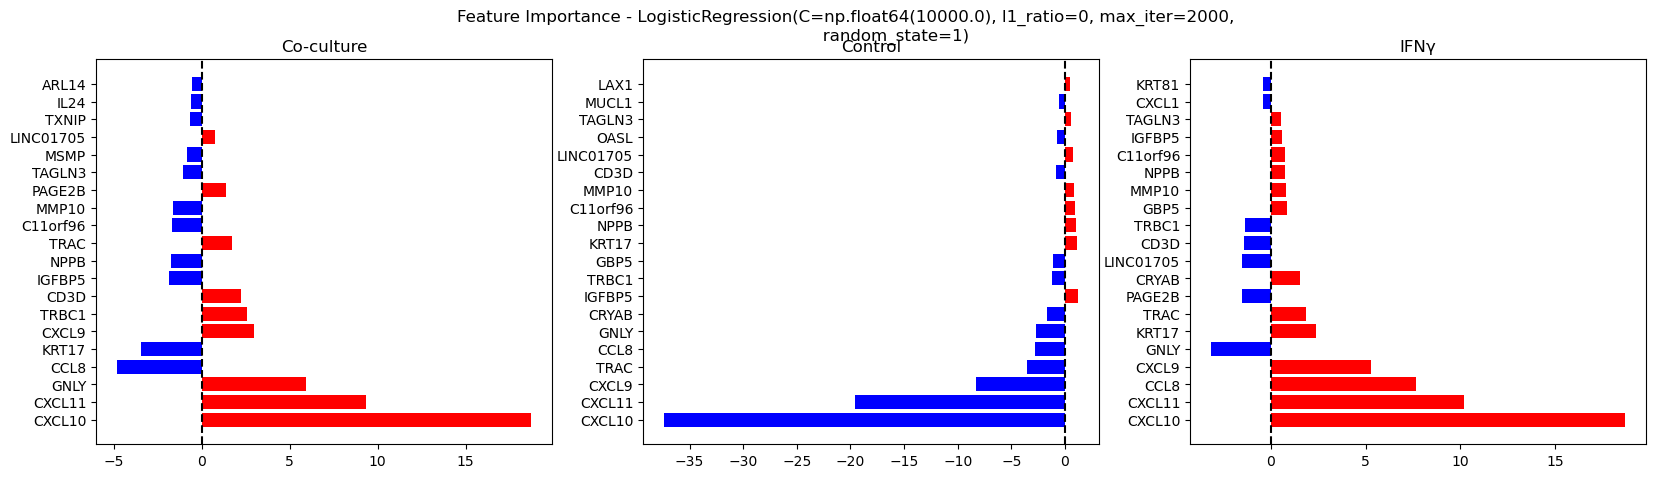

In [47]:
plt.figure(figsize = [20,5])

for i in range (3):

    coeff = best_logreg.named_steps['model'].coef_[i]
    abs_coeff = abs(coeff)
    sorted_idx = np.argsort(abs_coeff)
    top_features_genes = np.array(adata.var.index)[sorted_idx[::-1][0:20]]
    pos_mask = (coeff[sorted_idx[::-1][0:20]] > 0)
    
    plt.subplot(1, 3, i+1)
    plt.suptitle(f'Feature Importance - {str(best_logreg.get_params()['model'])}\n  ')
    plt.title(best_logreg.classes_[i])
    plt.barh(np.arange(20), coeff[sorted_idx[::-1][0:20]], color = 'blue')
    plt.barh(np.arange(20)[pos_mask], coeff[sorted_idx[::-1][0:20]][pos_mask], color = 'red')
    plt.axvline(0, color = 'black', linestyle='--')
    plt.yticks(np.arange(20), labels=top_features_genes)

plt.show()

#### 6.1.2 Logistic regression - Permutation based importance

In [48]:
perm_logreg = permutation_importance(
    best_logreg,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1 # Uses all available CPUs
    )

In [49]:
logreg_perm_df = pd.DataFrame({
    "gene": np.array(adata.var.index),
    "importance_mean": perm_logreg.importances_mean,
    "importance_std": perm_logreg.importances_std
    })
logreg_perm_df.sort_values(by="importance_mean",ascending=False)

,gene,importance_mean,importance_std
28,CXCL11,0.066413,0.008475
1,AKR1B10,0.036887,0.004456
30,CXCL9,0.036675,0.006172
56,KRT17,0.030034,0.004285
27,CXCL10,0.028088,0.006808
...,...,...,...
2,AKR1C1,-0.001100,0.002208
79,PAGE5,-0.001734,0.000499
51,IL1RL1,-0.001988,0.001989
33,EDN1,-0.002876,0.004675


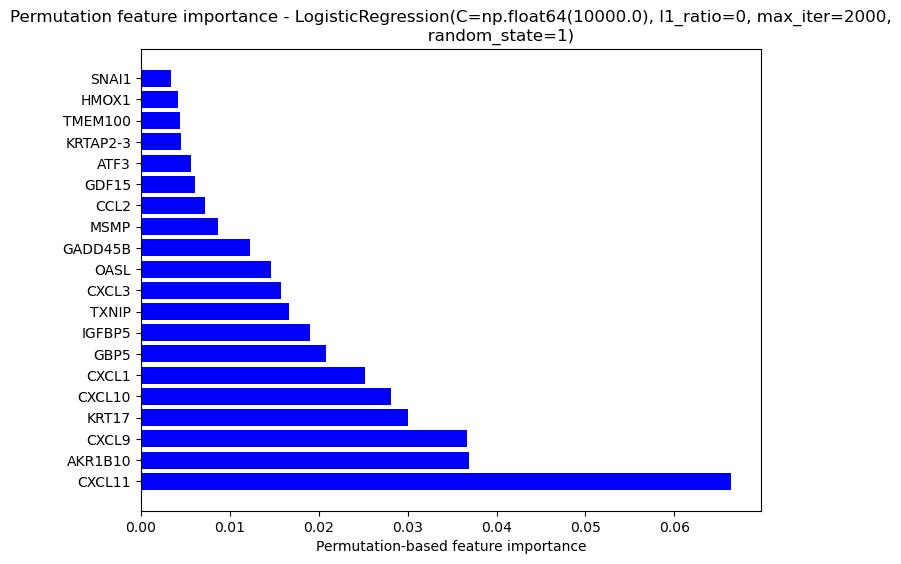

In [50]:
top20_sorted_df = logreg_perm_df.sort_values("importance_mean", ascending=False).head(20)
plt.figure(figsize=[8, 6])
plt.title(f"Permutation feature importance - {best_logreg.steps[1][1]}")
plt.barh(top20_sorted_df["gene"], top20_sorted_df["importance_mean"], color = 'blue')
plt.xlabel("Permutation-based feature importance")
plt.show()

### 6.2 Decision Tree 

#### 6.2.1 Decision Tree - Impurity based feature importance

In [51]:
tree_importance_df = pd.DataFrame({
    "gene": np.array(adata.var.index),
    "importance": best_tree.named_steps["model"].feature_importances_
    })
tree_importance_df

,gene,importance
0,AC005019.2,0.000000
1,AKR1B10,0.068331
2,AKR1C1,0.000000
3,AL591518.1,0.000000
4,AL603756.1,0.000000
...,...,...
95,TRAC,0.000000
96,TRBC1,0.000000
97,TXNIP,0.017280
98,VCX3B,0.000000


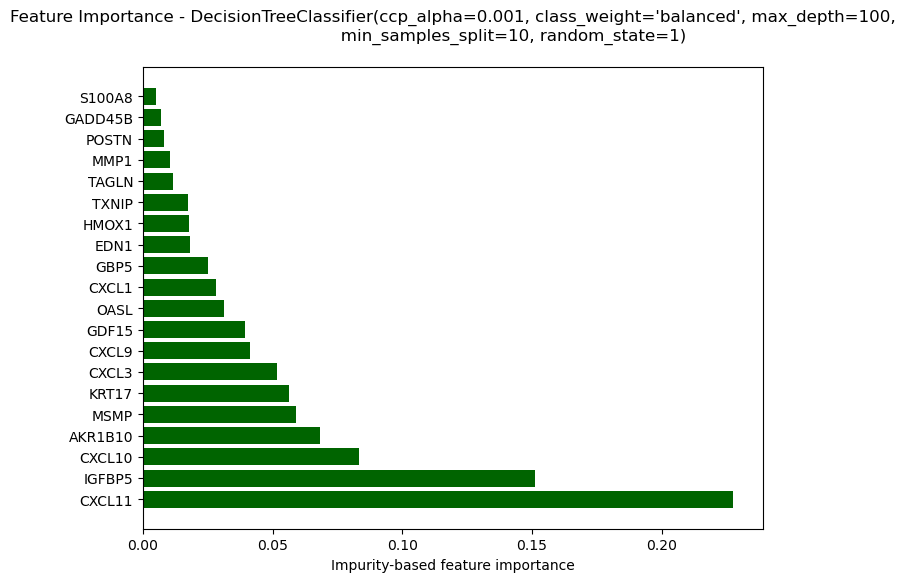

In [52]:
top20_sorted_df = tree_importance_df.sort_values("importance", ascending=False).head(20)
plt.figure(figsize=[8, 6])
plt.title(f'Feature Importance - {str(best_tree.get_params()['model'])}\n  ')
plt.barh(top20_sorted_df["gene"], top20_sorted_df["importance"], color = 'darkgreen')
plt.xlabel("Impurity-based feature importance")
plt.show()

#### 6.2.2 Decision Tree - Permutation based importance

In [53]:
perm_tree = permutation_importance(
    best_tree,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
    )

In [54]:
tree_perm_df = pd.DataFrame({
    "gene": np.array(adata.var.index),
    "importance_mean": perm_tree.importances_mean,
    "importance_std": perm_tree.importances_std
    })
tree_perm_df

,gene,importance_mean,importance_std
0,AC005019.2,0.000000,0.000000
1,AKR1B10,0.037437,0.005145
2,AKR1C1,0.000000,0.000000
3,AL591518.1,0.000000,0.000000
4,AL603756.1,0.000000,0.000000
...,...,...,...
95,TRAC,0.000000,0.000000
96,TRBC1,0.000000,0.000000
97,TXNIP,0.009137,0.003369
98,VCX3B,0.000000,0.000000


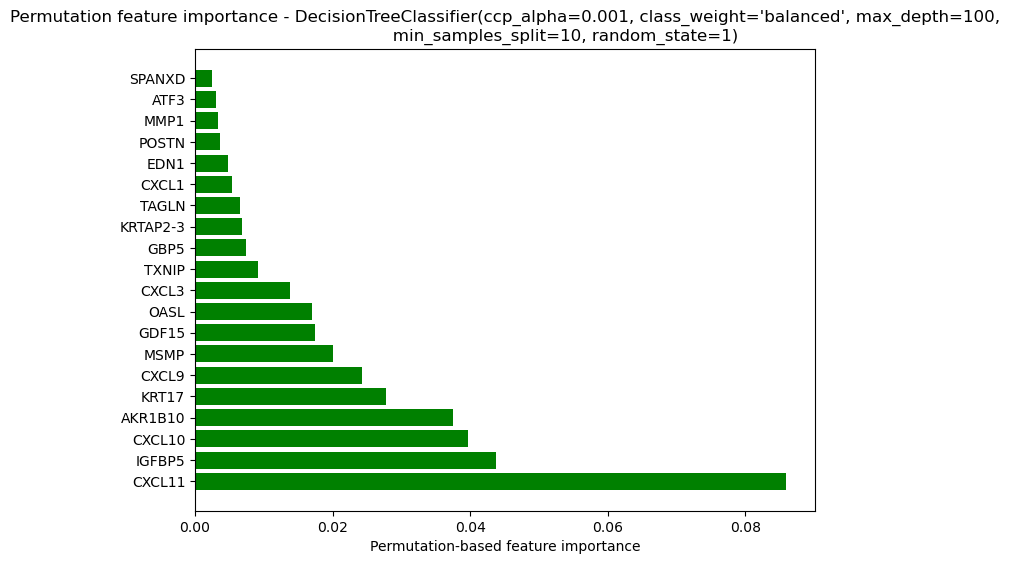

In [55]:
top20_sorted_df = tree_perm_df.sort_values("importance_mean", ascending=False).head(20)
plt.figure(figsize=[8, 6])
plt.title(f"Permutation feature importance - {best_tree.steps[0][1]}")
plt.barh(top20_sorted_df["gene"], top20_sorted_df["importance_mean"], color = 'green')
plt.xlabel("Permutation-based feature importance")
plt.show()